In [ ]:
# Perceptron trick  -- How to train a perceptron.

In [ ]:
'''
In the equation Ax+By+c=0,
  1) if c changes then line transform parallal(C increase then line goes downward, if C decrease then line goes upward.)
  2) if A changes then line transform in Y axis
  3) if B changes then line transform in X axis
Combinely they transform the line.

** If a negative point is on positive side then we wil add 1 on it's coordination and substract them from the actual line equation and apply. It will go to negative region.
** If a positive point is on negative side then we wil add 1 on it's coordination and add them with the actual line equation and apply. It will go to positive region.

new coordination = old coordination -or+ (learning rate*(point current coordination.))

'''

In [1]:
# Perceptron trick algo

In [ ]:
'''
epochs = 1000
learning rate n(ita) = 0.01

for i in range(epochs):
  randomly select a point/row
  if Xi belongs to Negative region and logistic function output belongs to positive region
    W_new = W_old - n(Xi)
  if Xi belongs to Positive region and logistic function output belongs to negative region
    W_new = W_old + n(Xi)

Simplified version-
Rather than checking these two conditions-

for i in range(epochs):
  randomly select a point/row
  W_new = W_old + n(Yi-Yi_bar)Xi

'''

In [2]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [3]:
import matplotlib.pyplot as plt

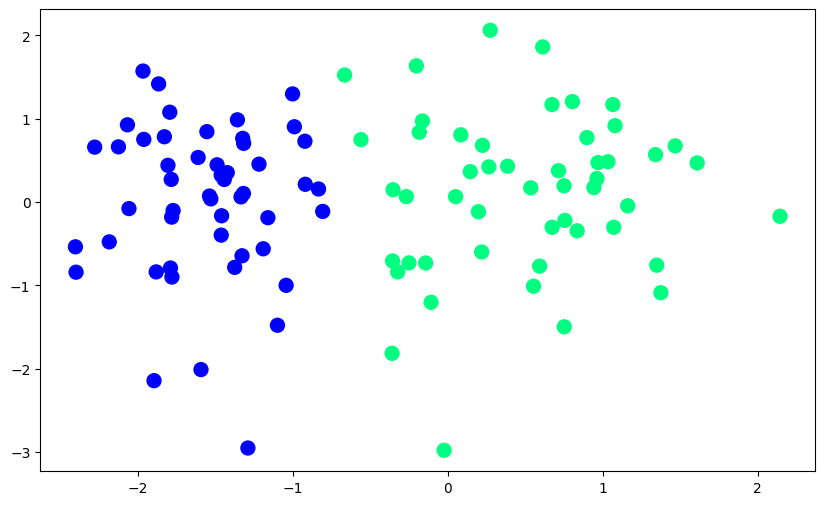

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [6]:
def perceptron(X,y):
  X = np.insert(X,0,1, axis = 1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]
  return weights[0], weights[1:]

In [7]:
def step(z):
  return 1 if z>0 else 0

In [8]:
intercept_, coef_ = perceptron(X,y)

In [9]:
print(intercept_, coef_)

1.0 [1.30633868 0.15637342]


In [10]:
m = -coef_[0]/coef_[1]
c = -intercept_/coef_[1]

In [12]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + c

(-3.0, 2.0)

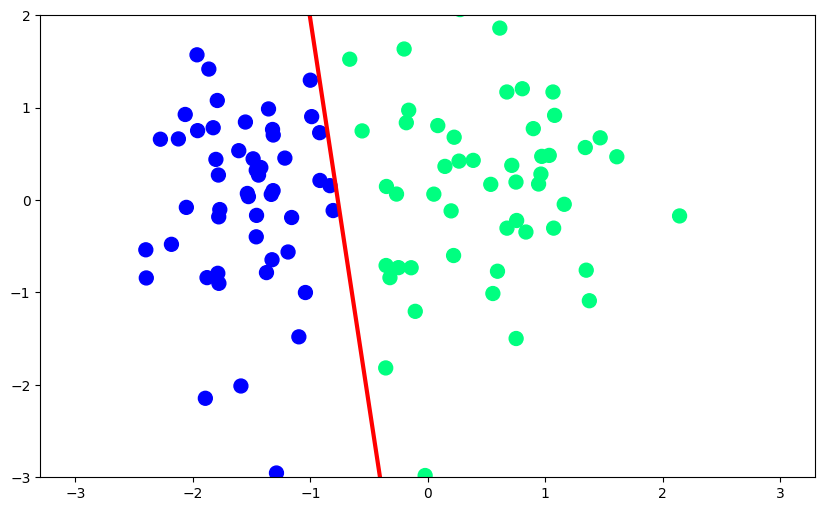

In [13]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)